In [1]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np


In [2]:
image = cv2.imread('1173876.png')

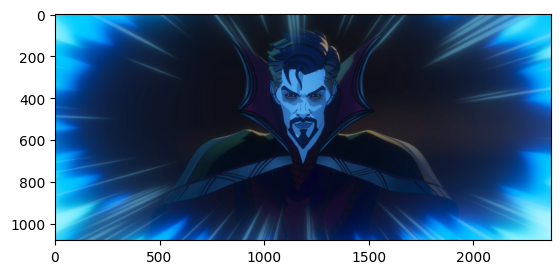

In [3]:
plt.imshow(image)

In [4]:
img=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)


In [5]:
img_grey=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)


(0.0, 255.0)

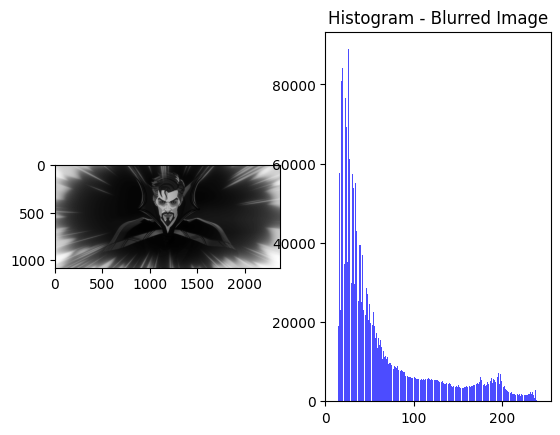

In [6]:
plt.subplot(1, 2, 1)
plt.imshow(img_grey,cmap='grey')
plt.subplot(1, 2, 2)
plt.hist(img_grey.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram - Blurred Image')
plt.xlim(0, 255)

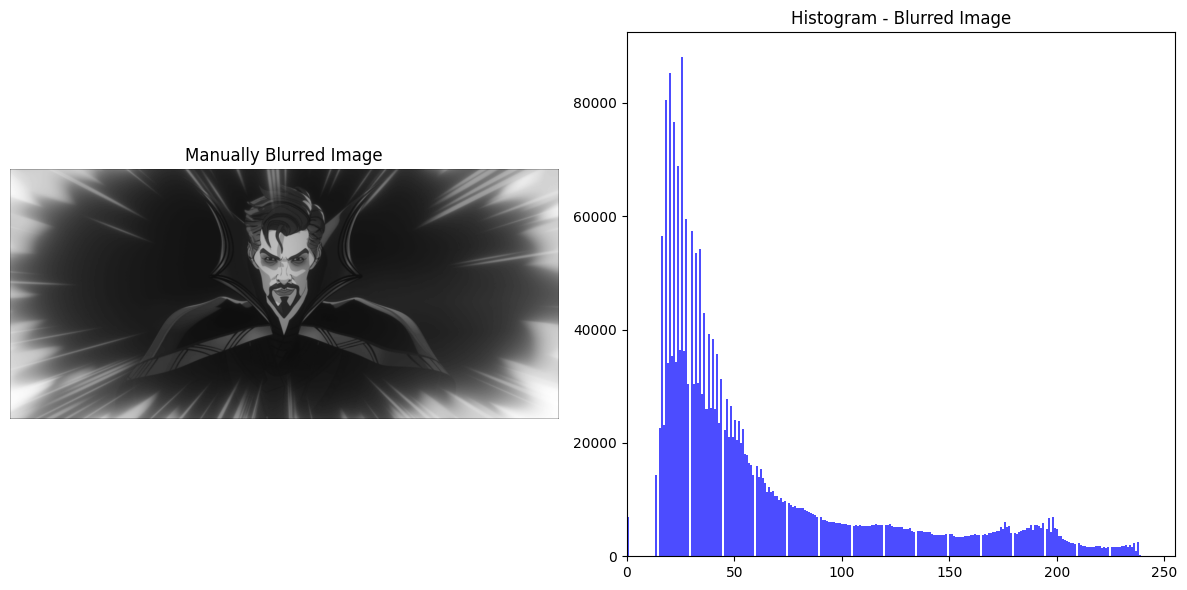

In [7]:

kernel_size = 3
offset = kernel_size // 2
original_image=img_grey
blurred_image = np.zeros_like(original_image)

for i in range(offset, original_image.shape[0] - offset):
    for j in range(offset, original_image.shape[1] - offset):
        region = original_image[i-offset:i+offset+1, j-offset:j+offset+1]
        blurred_image[i, j] = np.mean(region)
   
plt.figure(figsize=(12, 6))
   
plt.subplot(1, 2, 1)
plt.imshow(blurred_image, cmap='gray')
plt.title('Manually Blurred Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(blurred_image.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram - Blurred Image')
plt.xlim(0, 255)
   
plt.tight_layout()
plt.show()

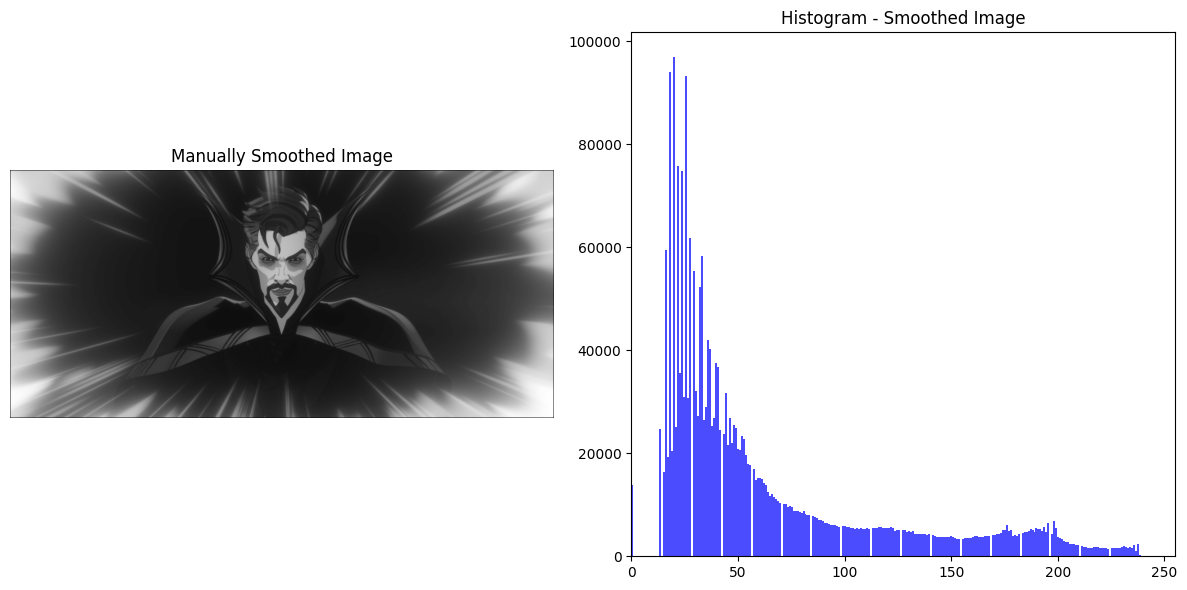

In [8]:
kernel_size = 5
offset = kernel_size // 2
   
   
sigma = 1
kernel = np.fromfunction(
    lambda x, y: (1 / (2 * np.pi * sigma**2)) * np.exp(-((x - 2)**2 + (y - 2)**2) / (2 * sigma**2)),
        (kernel_size, kernel_size)
)
kernel /= np.sum(kernel)  
smoothed_image = np.zeros_like(original_image)
for i in range(offset, original_image.shape[0] - offset):
    for j in range(offset, original_image.shape[1] - offset):
        region = original_image[i-offset:i+offset+1, j-offset:j+offset+1]
        smoothed_image[i, j] = np.sum(region * kernel)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(smoothed_image, cmap='gray')
plt.title('Manually Smoothed Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(smoothed_image.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram - Smoothed Image')
plt.xlim(0, 255)
   
plt.tight_layout()
plt.show()

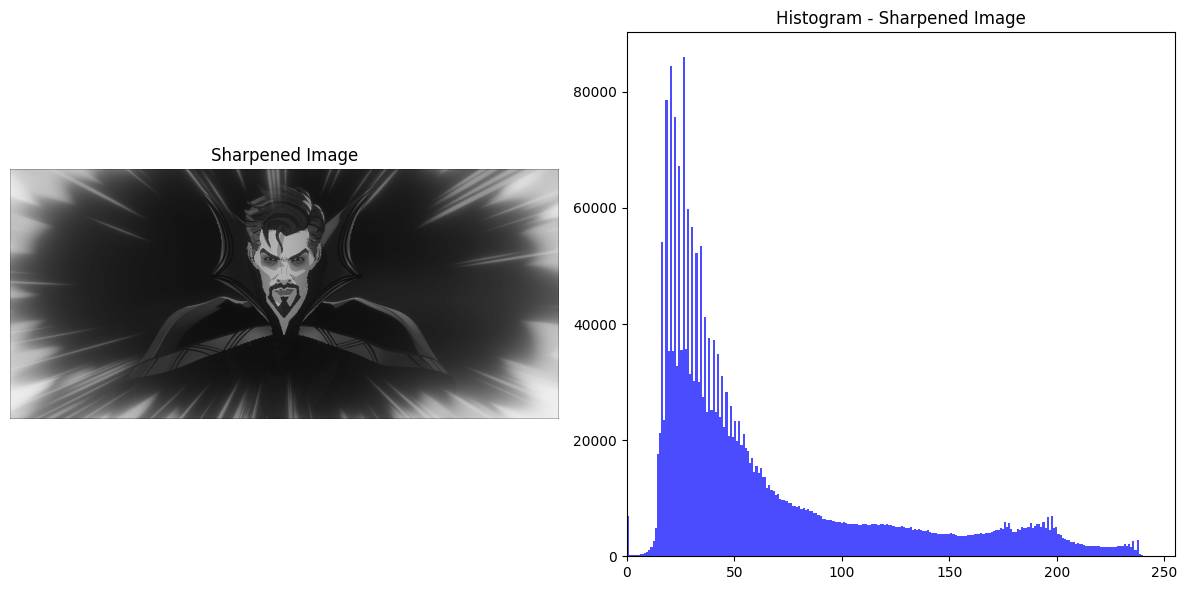

In [9]:
sharpening_kernel = np.array([[0, -1, 0],
                               [-1, 5,-1],
                               [0, -1, 0]])

offset = 1 
sharpened_image = np.zeros_like(original_image)

for i in range(offset, original_image.shape[0] - offset):
    for j in range(offset, original_image.shape[1] - offset):
        region = original_image[i-offset:i+offset+1, j-offset:j+offset+1]
        sharpened_image[i, j] = np.sum(region * sharpening_kernel)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(sharpened_image, cmap='gray')
plt.title('Sharpened Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(sharpened_image.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram - Sharpened Image')
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

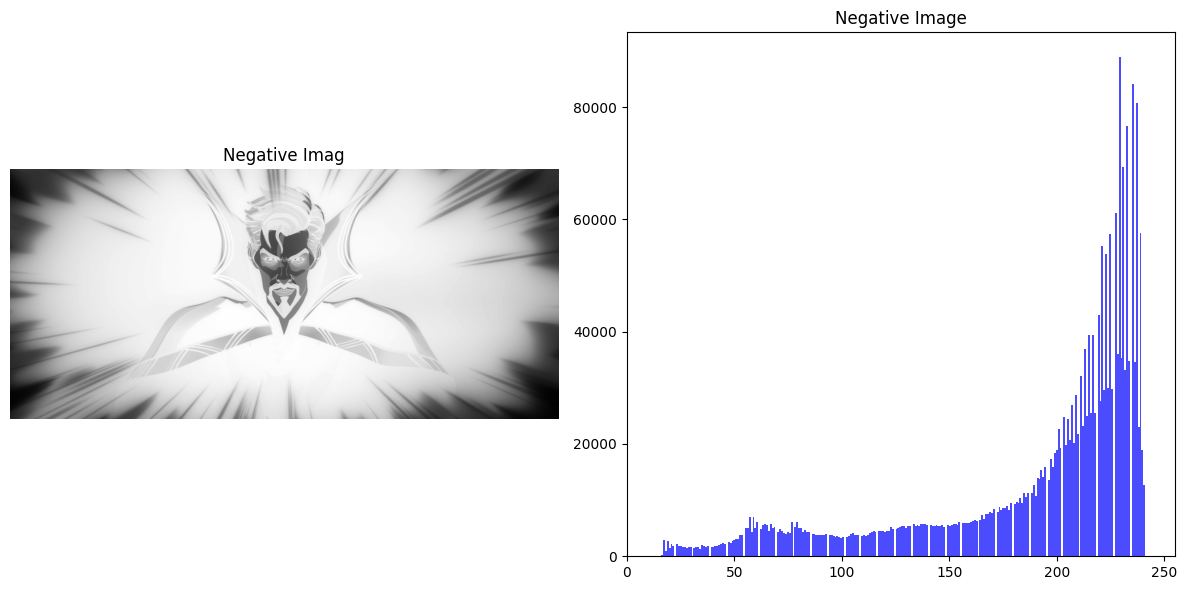

In [10]:
negative_img=255 - img_grey
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(negative_img, cmap='gray')
plt.title('Negative Imag')
plt.axis('off')

    # Show the histogram of the smoothed image
plt.subplot(1, 2, 2)
plt.hist(negative_img.ravel(), bins=256, color='blue', alpha=0.7)
plt.title("Negative Image")
plt.xlim(0, 255)
   
plt.tight_layout()
plt.show()

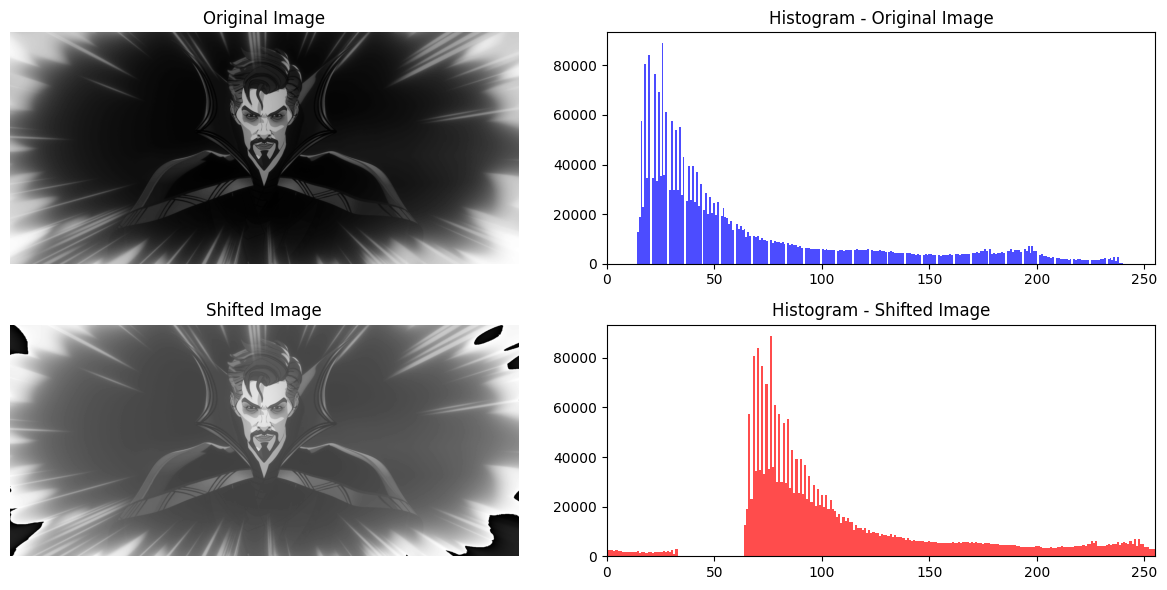

In [11]:
shift_value = 50
shifted_image = np.clip(original_image + shift_value, 0, 255).astype(np.uint8)

    # Step 2: Plot the original and shifted image with their histograms
plt.figure(figsize=(12, 6))

    # Show the original image
plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

    # Show the histogram of the original image
plt.subplot(2, 2, 2)
plt.hist(original_image.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram - Original Image')
plt.xlim(0, 255)

    # Show the shifted image
plt.subplot(2, 2, 3)
plt.imshow(shifted_image, cmap='gray')
plt.title('Shifted Image')
plt.axis('off')

    # Show the histogram of the shifted image
plt.subplot(2, 2, 4)
plt.hist(shifted_image.ravel(), bins=256, color='red', alpha=0.7)
plt.title('Histogram - Shifted Image')
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

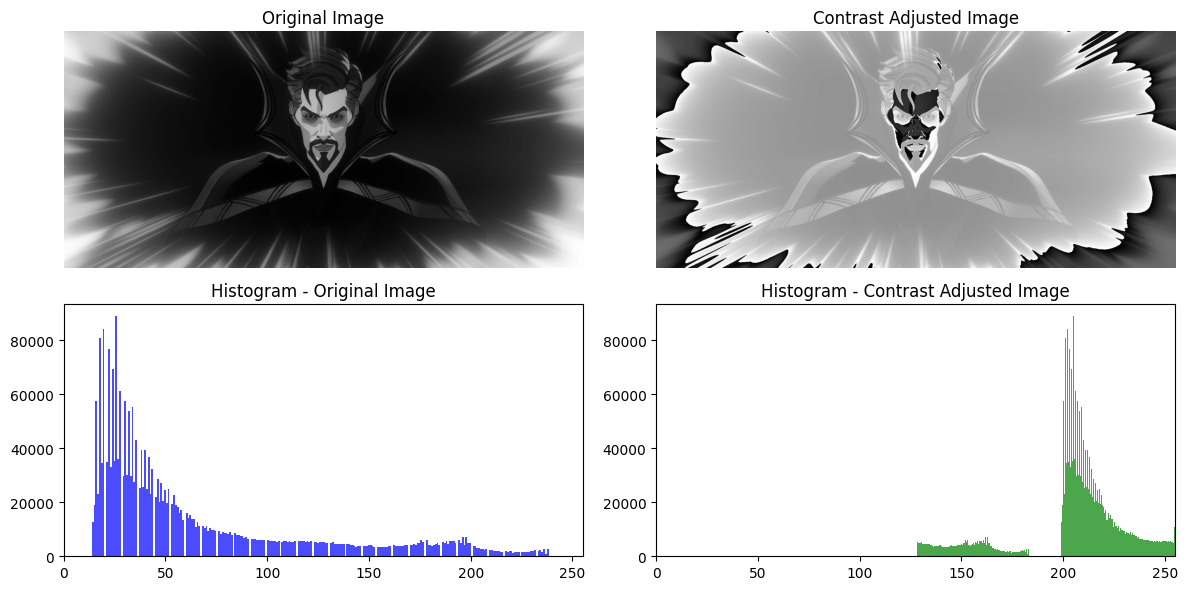

In [12]:
    alpha = 0.5  # Contrast increase factor (use alpha < 1 to decrease contrast)
   
    # Apply the contrast formula: new_pixel = alpha * (pixel - 128) + 128
    contrast_image = alpha * (original_image - 128) + 128
   
    # Clip the pixel values to ensure they stay within the valid range [0, 255]
    contrast_image = np.clip(contrast_image, 0, 255)
   
    # Plotting the original and contrast-adjusted image side by side
    plt.figure(figsize=(12, 6))
   
    # Show the original image
    plt.subplot(2, 2, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # Show the contrast-adjusted image
    plt.subplot(2, 2, 2)
    plt.imshow(contrast_image, cmap='gray')
    plt.title('Contrast Adjusted Image')
    plt.axis('off')
   
    # Plotting the histograms side by side
    # Histogram of the original image
    plt.subplot(2, 2, 3)
    plt.hist(original_image.ravel(), bins=256, color='blue', alpha=0.7)
    plt.title('Histogram - Original Image')
    plt.xlim(0, 255)
   
    # Histogram of the contrast-adjusted image
    plt.subplot(2, 2, 4)
    plt.hist(contrast_image.ravel(), bins=256, color='green', alpha=0.7)
    plt.title('Histogram - Contrast Adjusted Image')
    plt.xlim(0, 255)

    plt.tight_layout()
    plt.show()


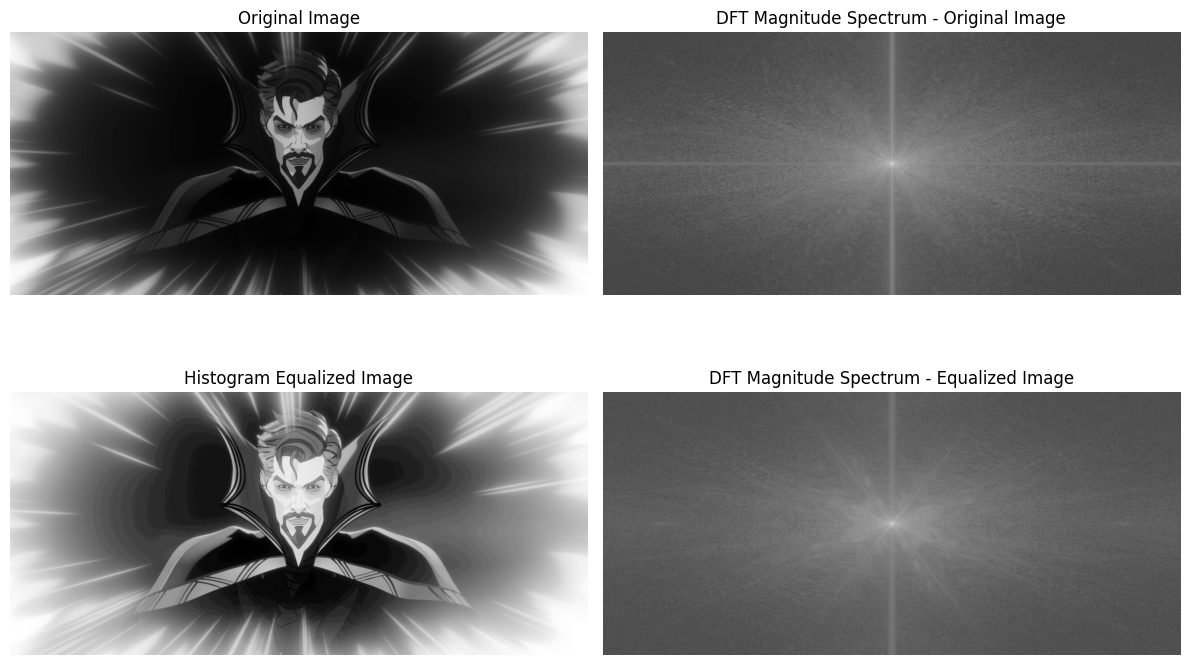

In [13]:
    equalized_image = cv2.equalizeHist(original_image)

    # Step 2: Perform DFT for original image
    dft_original = cv2.dft(np.float32(original_image), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift_original = np.fft.fftshift(dft_original)  # Shift zero-frequency component to center
    magnitude_spectrum_original = cv2.magnitude(dft_shift_original[:, :, 0], dft_shift_original[:, :, 1])

    # Step 3: Perform DFT for histogram-equalized image
    dft_equalized = cv2.dft(np.float32(equalized_image), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift_equalized = np.fft.fftshift(dft_equalized)  # Shift zero-frequency component to center
    magnitude_spectrum_equalized = cv2.magnitude(dft_shift_equalized[:, :, 0], dft_shift_equalized[:, :, 1])

    # Step 4: Plot the original and equalized image along with their magnitude spectra
    plt.figure(figsize=(12, 8))

    # Original Image and its DFT Magnitude Spectrum
    plt.subplot(2, 2, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(np.log(magnitude_spectrum_original + 1), cmap='gray')  # Log scale for better visualization
    plt.title('DFT Magnitude Spectrum - Original Image')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(equalized_image, cmap='gray')
    plt.title('Histogram Equalized Image')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(np.log(magnitude_spectrum_equalized + 1), cmap='gray')  # Log scale for better visualization
    plt.title('DFT Magnitude Spectrum - Equalized Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

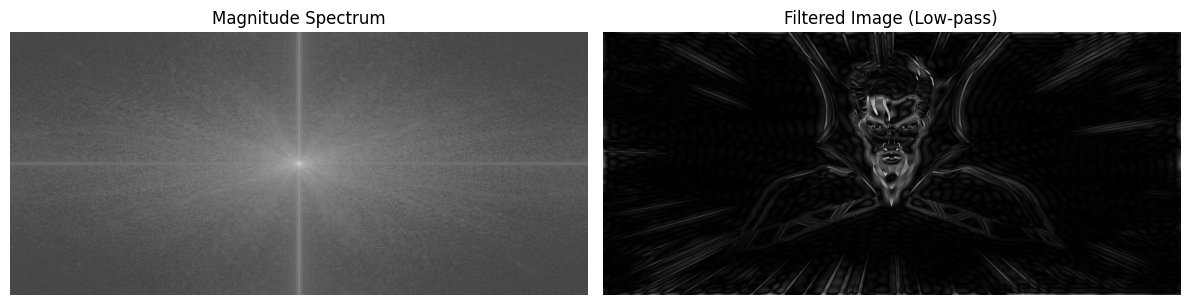

In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

original_image = img_grey


dft = cv2.dft(np.float32(original_image), flags=cv2.DFT_COMPLEX_OUTPUT)

dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])

magnitude_spectrum_log = np.log(magnitude_spectrum + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(magnitude_spectrum_log, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')


rows, cols = original_image.shape
crow, ccol = rows // 2, cols // 2 

mask = np.ones((rows, cols), np.uint8)
r = 30  
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = (x - center[0])**2 + (y - center[1])**2 <= r*r
mask[mask_area] = 0

dft_shift_filtered = dft_shift * mask[:, :, np.newaxis]

dft_ishift = np.fft.ifftshift(dft_shift_filtered)
img_back = cv2.idft(dft_ishift)

img_back_magnitude = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

plt.subplot(1, 2, 2)
plt.imshow(img_back_magnitude, cmap='gray')
plt.title('Filtered Image (Low-pass)')
plt.axis('off')

plt.tight_layout()
plt.show()
